##### Data preproccessing 

In [1]:
import os
import numpy as np
from rasterio.enums import Resampling

import sys
import os

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../.."))

In [2]:
SOUTHERN_INDIA_DS = r"H:\My Drive\Southern"
WESTERN_INDIA_DS = r"I:\My Drive\Western"

In [3]:
MASK_CLASSES = [3,8,9,10,11]

In [4]:
from services.preproccess import process_scene

In [7]:
OUTPUT_PATCH_DIR = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\western"

In [8]:

selected_scenes = ["scene1","scene3","scene8","scene10","scene11"]

for scene in selected_scenes:
    scene_path = os.path.join(WESTERN_INDIA_DS, scene)

    if os.path.isdir(scene_path):
        print(f"Processing {scene}...")
        patches = process_scene(scene, scene_path, OUTPUT_PATCH_DIR, MASK_CLASSES)
        print(f"Finished processing {scene}.")

Processing scene1...
1500 patches saved...
3000 patches saved...
4500 patches saved...
6000 patches saved...
Total patches saved: 7056
Finished processing scene1.
Processing scene3...
1500 patches saved...
3000 patches saved...
4500 patches saved...
6000 patches saved...
Total patches saved: 7056
Finished processing scene3.
Processing scene8...
1500 patches saved...
3000 patches saved...
4500 patches saved...
6000 patches saved...
Total patches saved: 6909
Finished processing scene8.
Processing scene10...
1500 patches saved...
3000 patches saved...
4500 patches saved...
6000 patches saved...
Total patches saved: 7056
Finished processing scene10.
Processing scene11...
1500 patches saved...
3000 patches saved...
4500 patches saved...
6000 patches saved...
Total patches saved: 7056
Finished processing scene11.


In [2]:
import os
import h5py

COUNT = 0
NO_OF_FILES = 0
ROOT_DS_PATCH_DIR = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches"

In [4]:
for folder in os.listdir(ROOT_DS_PATCH_DIR):
    folder_path = os.path.join(ROOT_DS_PATCH_DIR, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            file = h5py.File(file_path, "r")
            patches = file["patches"]
            COUNT += patches.shape[0]
            NO_OF_FILES += 1

print(f"Total number of patches: {COUNT}")
print(f"Total number of files: {NO_OF_FILES}")

Total number of patches: 213183
Total number of files: 32


In [3]:
FILE = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\central\scene2_patches.h5"

In [6]:
import h5py

file = h5py.File(FILE, "r")
print(list(file.keys()))

['patches']


In [7]:
patches = file["patches"]
print(patches.shape)

(7048, 9, 256, 256)


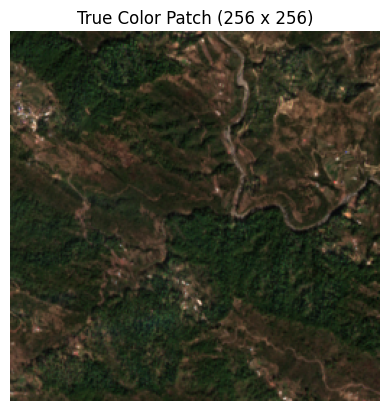

In [13]:
import matplotlib.pyplot as plt
import h5py
import numpy as np

with h5py.File(FILE, "r") as f:
    patch = f["patches"][4].astype(np.float32)  # convert dtype

# create RGB image
rgb = np.stack([
    patch[2],
    patch[1],
    patch[0]
    
], axis=-1)

# normalize for display
rgb = (rgb - np.nanmin(rgb)) / (np.nanmax(rgb) - np.nanmin(rgb))

plt.imshow(rgb)
plt.title("True Color Patch (256 x 256)")
plt.axis("off")
plt.show()

#### Feature Engineering

In [ ]:
FLLLLLLLEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE

In [2]:

import numpy as np
import os

from services.feature_eng import calculate_indices

In [3]:
PATCH_SPECIFIC_DIR = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\central"

In [ ]:
for file in os.listdir(PATCH_SPECIFIC_DIR):
    if file.endswith(".h5"):
        file_path = os.path.join(PATCH_SPECIFIC_DIR, file)
        print(f"Proccessing {file}...")
        
        calculate_indices(file_path)
        
        print(f"Finished proccessing {file}.")

Proccessing scene2_patches.h5...


c:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\soil_type_classification\services\feature_eng.py:29: RuntimeWarning: overflow encountered in divide
  FERROUS_RATIO = B11 / (B08 + eps)
